In [2]:
import os
import sys

# Get the absolute path of the directory containing the notebook (notebooks/)
current_dir = os.path.abspath('')

# Add the parent directory (SingleWordProductionDutch/) to the system path
# This allows Python to find 'src'
parent_dir = os.path.dirname(current_dir)
sys.path.append(parent_dir)


%load_ext autoreload
%autoreload 2

import numpy as np
import scipy.signal
from scipy.signal import hilbert
import matplotlib.pyplot as plt
from scipy.signal import welch

import pandas as pd
import numpy.matlib as matlib
import scipy
import scipy.stats
import scipy.io.wavfile
import scipy.fftpack
from scipy.stats import pearsonr
from pynwb import NWBHDF5IO

from somata.basic_models import OscillatorModel as Osc
from somata.oscillator_search import IterativeOscillatorModel as IterOsc
from somata.oscillator_search.helper_functions import get_knee
from specparam import SpectralModel

from phaseEM import *
from extract_features import *
from channel_evaluation import *
from reconstruction_minimal import *
import config as cfg
from notebookfunctions import *


feat_path = r'./features'
result_path = r'./results'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
#reconstruct(['sub-06','sub-07','sub-08','sub-09'])
reconstruct(['sub-07','sub-09'])


sub-07 has mean correlation of 0.703751
sub-09 has mean correlation of 0.484244


In [6]:
result_path = '/Users/lisa/Documents/DSAI_year2/SingleWordProductionDutch-1/results'
allRes = np.load(os.path.join(result_path,'SSPElinearResults.npy'))
randomControl = np.load(os.path.join(result_path,'SSPErandomResults.npy'))
explainedVariance = np.load(os.path.join(result_path,'SSPEexplainedVariance.npy'))

for p in range(0,4):
    print(p)
    rs = allRes[p]
    model_mean = rs.mean()
    rand_mean = randomControl[p].mean()
    rand_std = randomControl[p].std()
    z = (model_mean - rand_mean) / rand_std
    print(model_mean)
    print(rand_mean,"±",rand_std)
    print(explainedVariance[p].mean())

0
0.5309488839621564
0.012852369224693573 ± 0.31596840816866867
0.5032888154125681
1


IndexError: index 1 is out of bounds for axis 0 with size 1

nr of frequencies in somata results in total: 481
peak_freqs: [  1.7017017   13.27327327  27.73773774  61.26126126  73.51351351
  84.06406406  96.14614615 103.46346346 116.22622623 124.05405405
 130.69069069 151.11111111 163.02302302]


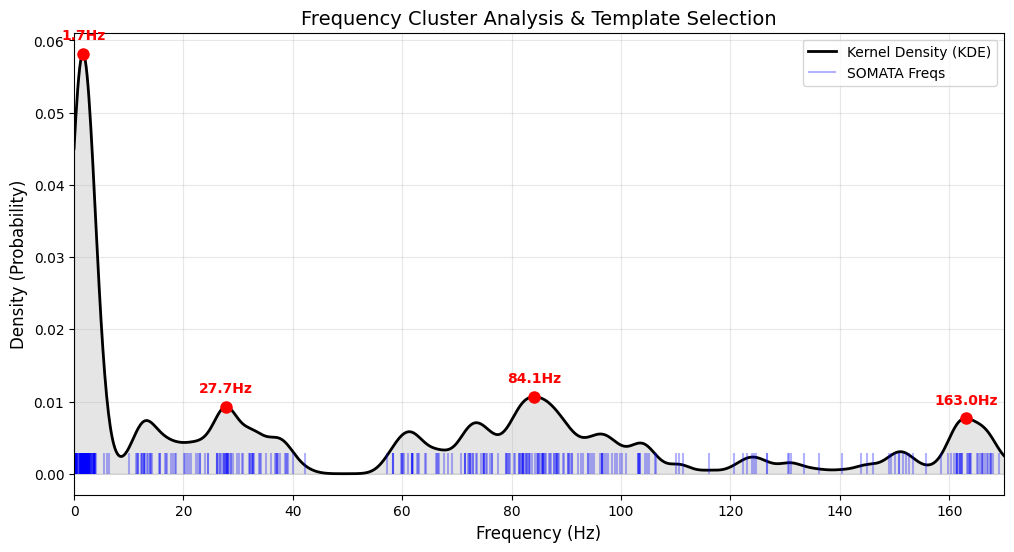

Original feature shape: (29991, 4572), nr_osc=503
HG-only feature shape:  (29991, 180)
sub-07 has mean correlation of 0.522578


In [8]:
print(f"Total Oscillators in initParams_list: {sum(len(p['freqs']) for p in initParams_list)}")
print(f"Features per Oscillator (approx): {4572 / 503:.2f}")

Total Oscillators in initParams_list: 503
Features per Oscillator (approx): 9.09


In [13]:
path_output = r'./features'


for pt in ['sub-01', 'sub-02', 'sub-03', 'sub-04', 'sub-09', 'sub-10']:
    io = NWBHDF5IO(os.path.join(cfg.PATH_BIDS, pt,'ieeg',f'{pt}_task-wordProduction_ieeg.nwb'), 'r')
    nwbfile = io.read()
    eeg = nwbfile.acquisition['iEEG'].data[:]
    io.close()

    initParams_list = get_initParams(pt)
    feat = extractSSPE(eeg, initParams_list)
    np.save(os.path.join(path_output,f'{pt}_unstacked_SSPEfeat.npy'), feat)

    feat = extractHG(eeg, 1024)
    np.save(os.path.join(path_output,f'{pt}_unstacked_feat.npy'), feat)


nr of frequencies in somata results in total: 395
Starting parallel SSPE extraction for 127 channels...
nr of frequencies in somata results in total: 307
Starting parallel SSPE extraction for 127 channels...
nr of frequencies in somata results in total: 478
Starting parallel SSPE extraction for 127 channels...
nr of frequencies in somata results in total: 304
Starting parallel SSPE extraction for 115 channels...
nr of frequencies in somata results in total: 304
Starting parallel SSPE extraction for 117 channels...
nr of frequencies in somata results in total: 346
Starting parallel SSPE extraction for 122 channels...


In [ ]:
reconstruct(['sub-01', 'sub-02', 'sub-03', 'sub-04', 'sub-09', 'sub-10'])

In [16]:
import numpy as np
import pandas as pd
import os

def reconstruct_with_range(pts_list, f_min, f_max):

    filtered_data_dict={}

    for pt in pts_list:
        
        # Load full features once per patient
        all_features = np.load(os.path.join(feat_path, f'{pt}_unstacked_SSPEfeat.npy'))
        
        initParams_list = get_initParams(pt)
        
        # Build frequency index
        brain_freqs = []
        for ch_dict in initParams_list:
            brain_freqs.extend(ch_dict['freqs'])
        brain_freqs = np.array(brain_freqs)

        mask = (brain_freqs >= f_min) & (brain_freqs <= f_max)
        
        filtered_data_dict[pt] = stackFeatures(all_features[:, mask]) 
        
        # Run the decoder
    reconstruct(pts=pts_list,  SSPEfeatures=False, hg_osc_sspe_features=True, data_dict=filtered_data_dict, saveAs='70_170_oscs')


pts = ['sub-01', 'sub-02', 'sub-03', 'sub-04', 'sub-05','sub-06','sub-07', 'sub-08', 'sub-09', 'sub-10']
df = reconstruct_with_range(pts, 70, 170)



nr of frequencies in somata results in total: 395
nr of frequencies in somata results in total: 307
nr of frequencies in somata results in total: 478
nr of frequencies in somata results in total: 304
nr of frequencies in somata results in total: 199
nr of frequencies in somata results in total: 67
nr of frequencies in somata results in total: 481
nr of frequencies in somata results in total: 174
nr of frequencies in somata results in total: 304
nr of frequencies in somata results in total: 346
29985 29985
sub-01 has mean correlation of 0.390181
29985 29985
sub-02 has mean correlation of 0.458108
29986 29986
sub-03 has mean correlation of 0.744658
29986 29986
sub-04 has mean correlation of 0.722357
29984 29984
sub-05 has mean correlation of 0.480513
29993 29993
sub-06 has mean correlation of 0.814357
29991 29991
sub-07 has mean correlation of 0.733188
29992 29992
sub-08 has mean correlation of 0.570820
29993 29993
sub-09 has mean correlation of 0.652857
28460 28460
sub-10 has mean corre

In [2]:
reconstruct(pts=None,  SSPEfeatures=True, hg_osc_sspe_features=False, data_dict=None, saveAs='all_oscs')

sub-01 has mean correlation of 0.313524
Max value in rec_spec: 1329019798485.6824


/Users/lisa/Documents/DSAI_year2/SingleWordProductionDutch-1/MelFilterBank.py:82: RuntimeWarning: overflow encountered in exp
  return(self.makeNormal(self.fromMelScale(np.exp(melSpectrogram))))


sub-02 has mean correlation of 0.511453
Max value in rec_spec: 14.338400829055898
sub-03 has mean correlation of 0.674847
Max value in rec_spec: 13.20799455856996
sub-04 has mean correlation of 0.694646
Max value in rec_spec: 13.2062874943541
sub-05 has mean correlation of 0.466138
Max value in rec_spec: 14.418434444582502
sub-06 has mean correlation of 0.794323
Max value in rec_spec: 13.095846382289267
sub-07 has mean correlation of 0.677045
Max value in rec_spec: 17.627173554717338
sub-08 has mean correlation of 0.523885
Max value in rec_spec: 13.363385818003172
sub-09 has mean correlation of 0.533890
Max value in rec_spec: 15.706002522042267
sub-10 has mean correlation of 0.514975
Max value in rec_spec: 18.40422445411699


In [23]:
reconstruct(pts=None,  SSPEfeatures=False, hg_osc_sspe_features=False, data_dict=None, saveAs='HG')

sub-01 has mean correlation of 0.519977
Max value in rec_spec: 12.383286462591272
sub-02 has mean correlation of 0.632364
Max value in rec_spec: 17.183642167107323
sub-03 has mean correlation of 0.837003
Max value in rec_spec: 15.0324547105092
sub-04 has mean correlation of 0.780109
Max value in rec_spec: 18.020566993577134
sub-05 has mean correlation of 0.532358
Max value in rec_spec: 15.343694817395686
sub-06 has mean correlation of 0.861970
Max value in rec_spec: 13.419966899733236
sub-07 has mean correlation of 0.707043
Max value in rec_spec: 18.47523362390214
sub-08 has mean correlation of 0.715179
Max value in rec_spec: 16.803860368154886
sub-09 has mean correlation of 0.657480
Max value in rec_spec: 18.819468673357488
sub-10 has mean correlation of 0.692957
Max value in rec_spec: 22.864451000449375


(10, 10, 23)
(10, 10, 23)


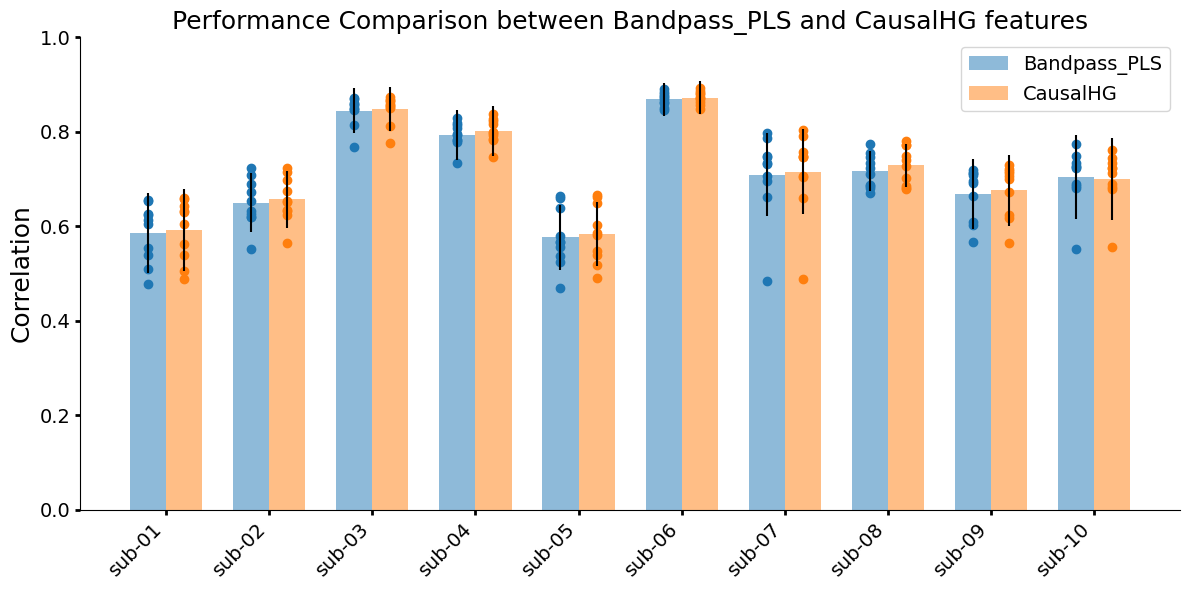

In [3]:
'''def viz_compare_results(prefix_a, prefix_b):
    result_path = r'./results'
    #Load correlation results
    

    allRes_a = np.load(os.path.join(result_path, f'{prefix_a}linearResults.npy'))
    randomControl_a = np.load(os.path.join(result_path, f'{prefix_a}randomResults.npy'))
    explainedVariance_a = np.load(os.path.join(result_path,f'{prefix_a}explainedVariance.npy'))

    allRes_b = np.load(os.path.join(result_path, f'{prefix_b}linearResults.npy'))
    randomControl_b = np.load(os.path.join(result_path, f'{prefix_b}randomResults.npy'))
    explainedVariance_b = np.load(os.path.join(result_path,f'{prefix_b}explainedVariance.npy'))


    print(allRes_a.shape)
    print(allRes_b.shape)
    
    mean_a = np.mean(allRes_a, axis=(1, 2))
    std_a = np.std(allRes_a, axis=(1, 2))
    
    mean_b = np.mean(allRes_b, axis=(1, 2))
    std_b = np.std(allRes_b, axis=(1, 2))

    colors = ['C' + str(i) for i in range(10)]
    x = np.arange(len(mean_a))

    width = 0.35  # Width of the individual bars

    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot Method A bars (left side of the tick)
    rects1 = ax.bar(x - width/2, mean_a, width, yerr=std_a, 
                    label='HG bandpass', alpha=0.5, color='C' + str(0)) #'steelblue')
    
    # Plot Method B bars (right side of the tick)
    rects2 = ax.bar(x + width/2, mean_b, width, yerr=std_b, 
                    label='SSPE oscillators', alpha=0.5, color='C' + str(1)) #'indianred')

    # Add scatter points for individual observations
    for p in range(0,10):
        # Scatter for Method A
        vals_a = np.mean(allRes_a[p], axis=1)
        ax.scatter(np.repeat(p - width/2, len(vals_a)), vals_a, color='C' + str(0))
                   #color='black', s=15, alpha=0.5, zorder=3)
        
        # Scatter for Method B
        vals_b = np.mean(allRes_b[p], axis=1)
        ax.scatter(np.repeat(p + width/2, len(vals_b)), vals_b,  color='C' + str(1))
                   #color='black', s=15, alpha=0.5, zorder=3)

    # Styling
    ax.set_ylabel('Correlation', fontsize=18)
    ax.set_title('Performance Comparison between bandpass and SSPE features with PLS', fontsize=18)#, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels([f'sub-{i+1:02d}' for i in x], rotation=45, ha='right', fontsize=14)
    ax.set_ylim(0, 1)
    
    # Clean up spines
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=14, width=2)
    
    # Add a legend to distinguish methods
    ax.legend(fontsize=14)

    plt.tight_layout()
    plt.savefig(os.path.join(result_path,f'comparison_results.png'),dpi=600)
    plt.show()
    
    '''


viz_compare_results('Bandpass_PLS', 'CausalHG')

In [7]:

data_dict={}

for pt in ['sub-01', 'sub-02', 'sub-03', 'sub-04', 'sub-05','sub-06','sub-07', 'sub-08', 'sub-09', 'sub-10']:
    
    # Load full features once per patient
    feat = np.load(os.path.join(feat_path, f'{pt}_causalfeat.npy'))
    data_dict[pt] = feat

reconstruct(pts=None, n_comp = 5, SSPEfeatures=False, given_data=True, data_dict=data_dict, saveAs='CausalHG')

sub-01 has mean correlation of 0.592222
sub-02 has mean correlation of 0.657185
sub-03 has mean correlation of 0.847809
sub-04 has mean correlation of 0.800990
sub-05 has mean correlation of 0.584369
sub-06 has mean correlation of 0.872563
sub-07 has mean correlation of 0.715264
sub-08 has mean correlation of 0.728892
sub-09 has mean correlation of 0.676462
sub-10 has mean correlation of 0.700891


(array([[[0.370615  , 0.43127458, 0.54013458, ..., 0.46879607,
          0.46035646, 0.41738393],
         [0.61863818, 0.65061491, 0.67464146, ..., 0.5819407 ,
          0.5548093 , 0.50793258],
         [0.49323838, 0.522165  , 0.55192209, ..., 0.34762337,
          0.31157933, 0.2659832 ],
         ...,
         [0.4921673 , 0.52836114, 0.56436666, ..., 0.47456685,
          0.46116586, 0.42681346],
         [0.62442484, 0.66372165, 0.70080336, ..., 0.55907152,
          0.53673759, 0.476124  ],
         [0.64798078, 0.67067187, 0.68683993, ..., 0.50897677,
          0.49228255, 0.43110456]],
 
        [[0.65249031, 0.65240111, 0.66457902, ..., 0.65840404,
          0.63562743, 0.55628988],
         [0.66743299, 0.68129195, 0.6897508 , ..., 0.60661801,
          0.57815507, 0.49578062],
         [0.63361024, 0.65928403, 0.66033649, ..., 0.5989828 ,
          0.57842899, 0.52482926],
         ...,
         [0.72188122, 0.72670801, 0.73944455, ..., 0.66280766,
          0.62454939, 0.